# Analysis of Outcomes

In [29]:
import pandas as pd
df = pd.read_csv("output.csv")

## Likert Scale Plots

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_likert(df, field_value, likert_map):
    """
    Centered (diverging) Likert distribution plot for a single question.
    Positive (lower scores) appear at the top, negative (higher scores) at the bottom.
    Median/mean bar is centered on the 0 line, half-width left/right, count displayed to the right.
    Count labels appear at the end of each bar.
    Bars thicker, y-axis labels bold.
    Reference dashed lines at ±25%, ±50%, ±75%.
    X-axis limited to ±75%.
    Saves the plot as 'plots/<field_value>.pdf'.
    """

    # --- Validate columns ---
    for col in ["field", "value"]:
        if col not in df.columns:
            raise KeyError(f"Missing required column: '{col}'")

    # --- Filter data ---
    filtered = df[df["field"] == field_value].copy()
    if filtered.empty:
        print(f"No data found for field = {field_value}")
        return

    # --- Detect mapping direction ---
    first_key = next(iter(likert_map))
    if isinstance(first_key, str):
        label_to_score = likert_map
        score_to_label = {v: k for k, v in likert_map.items()}
    else:
        score_to_label = likert_map
        label_to_score = {v: k for k, v in likert_map.items()}

    # --- Convert 'value' to numeric ---
    try:
        filtered["score"] = filtered["value"].astype(int)
        filtered["label"] = filtered["score"].map(score_to_label)
    except ValueError:
        filtered["label"] = filtered["value"]
        filtered["score"] = filtered["value"].map(label_to_score)

    # --- Handle unmapped values ---
    if filtered["score"].isna().any():
        unmapped = filtered.loc[filtered["score"].isna(), "value"].unique()
        print(f"⚠️ Unmapped Likert values found: {list(unmapped)}")

    # --- Sort Likert scale order numerically ---
    order = sorted(score_to_label.items(), key=lambda x: x[0])
    scores = [s for s, _ in order]
    labels = [l for _, l in order]
    counts = filtered["label"].value_counts().reindex(labels, fill_value=0)
    total = counts.sum()
    percents = (counts / total) * 100

    # --- Median/Mean (round up if necessary) ---
    median_score = int(np.median(scores))
    neutral_label = score_to_label.get(median_score, None)

    # --- Build color map (green → red) ---
    norm_vals = (np.array(scores) - min(scores)) / (max(scores) - min(scores))
    colors = plt.cm.RdYlGn_r(norm_vals)
    color_map = dict(zip(labels, colors))

    # --- Split sides ---
    pos_labels = [l for s, l in order if s < median_score]  # lower = positive
    neg_labels = [l for s, l in order if s > median_score]  # higher = negative

    # --- Combine all labels for consistent y-axis order (top-to-bottom) ---
    full_order = pos_labels[::-1] + ([neutral_label] if neutral_label else []) + neg_labels

    # --- Plot ---
    n_bars = len(full_order)
    fig_height = max(3, n_bars * 0.5)
    fig, ax = plt.subplots(figsize=(7, fig_height))
    bar_height = 0.45

    # Plot positive bars (right side)
    for l in pos_labels:
        ax.barh(l, percents[l], color=color_map[l], edgecolor="none", height=bar_height)
        ax.text(percents[l] + 1, l, f"{counts[l]}", va="center", ha="left", fontsize=9, color="#333")

    # Plot neutral/median bar (centered)
    if neutral_label:
        width = percents[neutral_label]
        ax.barh(neutral_label, width, left=-width/2, color=color_map[neutral_label],
                edgecolor="none", height=bar_height)
        # Place count at the right end of the bar
        ax.text(width/2 + 1, neutral_label, f"{counts[neutral_label]}", va="center", ha="left",
                fontsize=9, color="#333")

    # Plot negative bars (left side)
    for l in neg_labels:
        ax.barh(l, -percents[l], color=color_map[l], edgecolor="none", height=bar_height)
        ax.text(-percents[l] - 1, l, f"{counts[l]}", va="center", ha="right", fontsize=9, color="#333")

    # --- Reference dashed lines at ±25, ±50, ±75 ---
    for x in [-75, -50, -25, 25, 50, 75]:
        ax.axvline(x=x, color='lightgray', linestyle='--', linewidth=0.8, alpha=0.7)
    # Center line
    ax.axvline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

    # --- Aesthetics ---
    ax.set_xlabel("Percentage of Responses (%)", fontsize=11)
    #ax.set_title(field_value, fontsize=13, weight="bold", pad=12)

    # Limit x-axis to ±75%
    ax.set_xlim(-75, 75)
    ax.set_xticks(np.arange(-75, 76, 25))
    ax.set_xticklabels([f"{abs(x)}%" for x in np.arange(-75, 76, 25)])
    ax.set_yticks(full_order)
    ax.set_yticklabels(full_order, fontweight='bold')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#aaa")
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(False)

    # --- Save figure ---
    os.makedirs("plots", exist_ok=True)
    plt.tight_layout()

    plt.savefig(f"plots/{field_value}.pdf", dpi=600)
    plt.show()


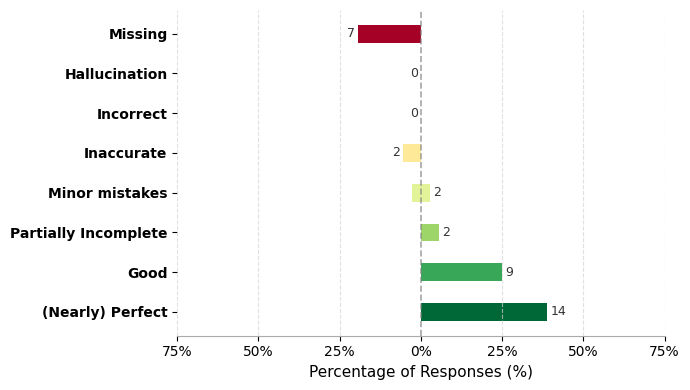

In [102]:
# Generate the Plot for Hypothesis
plot_likert(
    df=df,
    field_value='Hypothesis Likert Score',
    likert_map= {
        "(Nearly) Perfect": 1,
        "Good": 2,
        "Partially Incomplete": 3,
        "Minor mistakes": 4,
        "Inaccurate": 5,
        "Incorrect": 6,
        "Hallucination": 7,
        "Missing": 8,
    }
)

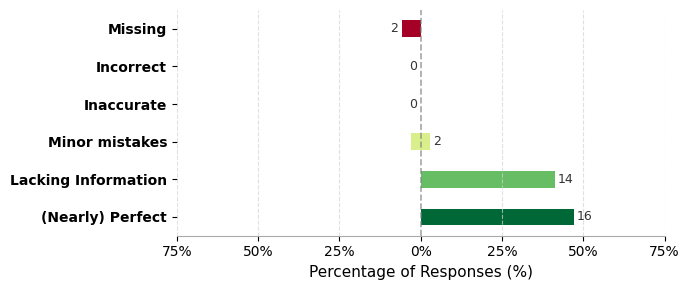

In [103]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Experiment Description Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "(Nearly) Perfect": 1,
        "Lacking Information": 2,
        "Minor mistakes": 3,
        "Inaccurate": 4,
        "Incorrect": 5,
        "Missing": 6,
    }
)

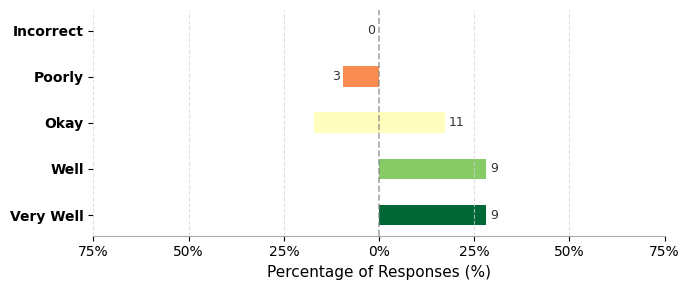

In [104]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Experiment Details Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "Very Well": 1,
        "Well": 2,
        "Okay": 3,
        "Poorly": 4,
        "Incorrect": 5,
    }
)

In [105]:
df[df["field"] == "Experiment Details Likert Score"]

,Paper,section,field,value
58,Robustness Distributions in Neural Network Ver...,experiment_1,Experiment Details Likert Score,3
69,Robustness Distributions in Neural Network Ver...,experiment_2,Experiment Details Likert Score,3
80,Robustness Distributions in Neural Network Ver...,experiment_3,Experiment Details Likert Score,3
143,Instance selection for configuration performan...,experiment_1,Experiment Details Likert Score,3
154,Instance selection for configuration performan...,experiment_2,Experiment Details Likert Score,1
190,Edge-Based Graph Component Pooling,experiment_1,Experiment Details Likert Score,2
228,Combining Automated Optimisation of Hyperparam...,experiment_1,Experiment Details Likert Score,2
273,Applying and benchmarking a stochastic program...,experiment_1,Experiment Details Likert Score,1
327,Examining the robustness of Physics-Informed N...,experiment_1,Experiment Details Likert Score,4
338,Examining the robustness of Physics-Informed N...,experiment_2,Experiment Details Likert Score,4


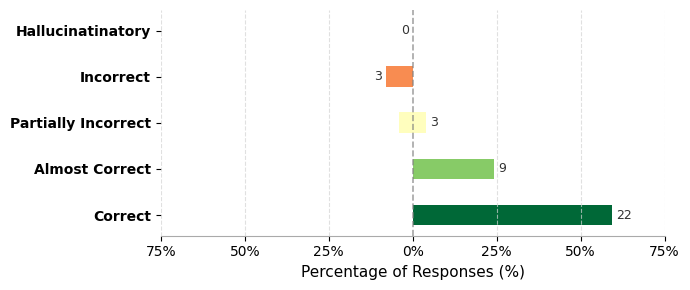

In [106]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Interpretation Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "Correct": 1,
        "Almost Correct": 2,
        "Partially Incorrect": 3,
        "Incorrect": 4,
        "Hallucinatinatory": 5,
    }
)

## Calculate Metrics for the paper

In [ ]:
# Calculate corrected statements
sub_df = df[df["field"] == "Hypothesis Corrected"]
corrected_hypothesis_statements = (sub_df['value'].notna()).sum()
corrected_hypothesis_statements_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Hypothesis: {corrected_hypothesis_statements} ({corrected_hypothesis_statements_p:.2f}%)")

sub_df = df[df["field"] == "Interpretation Corrected"]
corrected_interpretation_statements = (sub_df['value'].notna()).sum()
corrected_interpretation_statements_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Interpretations: {corrected_interpretation_statements} ({corrected_interpretation_statements_p:.2f}%)")

# Number of fully represented papers
papers = df["Paper"].unique().tolist()
complete_papers = 0
for p in papers:
    sub_df = df[df["Paper"] == p]
    if (sub_df[sub_df["field"] == "Hypothesis Likert Score"]["value"].astype(int) >= 8).sum() > 0:
        continue # Had missing hypothesis
    if (sub_df[sub_df["field"] == "Experiment Description Likert Score"]["value"].astype(int) >= 6).sum() > 0:
        continue # Had missing experiments
    complete_papers += 1

print(f"Number of completely represented papers: {complete_papers} ({(complete_papers / len(papers)) * 100:.2f}%)")

Number of corrected Hypothesis: 19 (65.52%)
Number of corrected Hypothesis: 9 (24.32%)
Number of completely represented papers: 15 (75.00%)


In [108]:
# Calculate Levensteihn distance between Hypothesis/Interpretation statements and the LLM definition
import json
from pathlib import Path
import nltk

sub_df = df[df["field"] == "Hypothesis Corrected"]
corrections = []
for _, row in sub_df.iterrows():
    corrected = row["value"]
    paper = row["Paper"]
    llm_output_path = Path(f"llm_output/{paper}.json")
    hypothesis_id = row["section"]
    original = json.load(open(llm_output_path))["Hypothesis"][hypothesis_id]["hypothesis"]
    if not isinstance(corrected, str) or corrected.strip() == "":
        corrections.append((0, len(original)))
    else:
        corrections.append((min(nltk.edit_distance(original, corrected), len(original)), len(original)))

average_edit_distance_hypothesis = sum([x[0] for x in corrections]) / len(corrections)
average_edit_distance_hypothesis_p = (sum([x[0] for x in corrections]) / sum([x[1] for x in corrections])) * 100
print(f"Average Hypothesis edit distance: {average_edit_distance_hypothesis:.2f} ({average_edit_distance_hypothesis_p:.2f}%)")

sub_df = df[df["field"] == "Interpretation Corrected"]
corrections = []
for _, row in sub_df.iterrows():
    corrected = row["value"]
    paper = row["Paper"]
    llm_output_path = Path(f"llm_output/{paper}.json")
    interpretation_id = row["section"]
    original = json.load(open(llm_output_path))["Interpretation"][interpretation_id]["reason"]
    if not isinstance(corrected, str) or corrected.strip() == "":
        corrections.append((0, len(original)))
    else:
        corrections.append((min(nltk.edit_distance(original, corrected), len(original)), len(original)))
        
average_edit_distance_interpretation = sum([x[0] for x in corrections]) / len(corrections)
average_edit_distance_interpretation_p = (sum([x[0] for x in corrections]) / sum([x[1] for x in corrections])) * 100
print(f"Average Hypothesis edit distance: {average_edit_distance_interpretation:.2f} ({average_edit_distance_interpretation_p:.2f}%)")

Average Hypothesis edit distance: 42.69 (14.90%)
Average Hypothesis edit distance: 34.65 (4.79%)


In [109]:
# Calculate how many links between hypthesis, experiments and interpretation were made
sub_df = df[df["field"] == "Experiment Corrected Hypotheses"]
experiment_corrected_hypotheses = (sub_df['value'].notna()).sum()
experiment_corrected_hypotheses_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Experiment Hypothesis links: {experiment_corrected_hypotheses} ({experiment_corrected_hypotheses_p:.2f}%)")
sub_df = df[df["field"] == "Interpretation Corrected Hypotheses"]
interpretation_corrected_hypotheses = (sub_df['value'].notna()).sum()
interpretation_corrected_hypotheses_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Interpretation Hypothesis links: {interpretation_corrected_hypotheses} ({interpretation_corrected_hypotheses_p:.2f}%)")
sub_df = df[df["field"] == "Interpretation Corrected Experiments"]
interpretation_corrected_experiments = (sub_df['value'].notna()).sum()
interpretation_corrected_experiments_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Interpretation Experiments links: {interpretation_corrected_experiments} ({interpretation_corrected_experiments_p:.2f}%)")

Number of corrected Experiment Hypothesis links: 6 (18.75%)
Number of corrected Interpretation Hypothesis links: 0 (0.00%)
Number of corrected Interpretation Experiments links: 2 (5.41%)


In [110]:
# Calculate how many mistakes were made in experiment details
sub_df = df[df["field"] == "Experiment Results Missing"]
missing_results = sub_df['value'].astype(int).sum()
print("Number of missing Experiment Results:", missing_results)

sub_df = df[df["field"] == "Experiment Results Wrong"]
wrong_results = sub_df['value'].astype(int).sum()
print("Number of wrong Experiment Results:", wrong_results)

sub_df = df[df["field"] == "Experiment Results Correct"]
corrected_results = sub_df['value'].astype(int).sum()
print("Number of correct Experiment Results:", corrected_results)
mistake_percentage_results = ((missing_results + wrong_results) / (corrected_results + missing_results + wrong_results)) * 100
print(f"Mistake percentage: {mistake_percentage_results:.2f}%")
print()

sub_df = df[df["field"] == "Experiment Corrected Metrics"]
corrected_metrics = (sub_df['value'].notna()).sum()
corrected_metrics_percentage = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Percentage of Experiment Corrected Metrics: {corrected_metrics_percentage:.2f}%")

sub_df = df[df["field"] == "Experiment Corrected Statistics"]
corrected_statistics = (sub_df['value'].notna()).sum()
corrected_statistics_percentage = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Percentage of Experiment Corrected Statistics: {corrected_statistics_percentage:.2f}%")

sub_df = df[df["field"] == "Experiment Corrected Strategy"]
corrected_strategy = (sub_df['value'].notna()).sum()
corrected_strategy_percentage = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Percentage of Experiment Corrected Strategy: {corrected_strategy_percentage:.2f}%")

Number of missing Experiment Results: 1037
Number of wrong Experiment Results: 66
Number of correct Experiment Results: 481
Mistake percentage: 69.63%

Percentage of Experiment Corrected Metrics: 46.88%
Percentage of Experiment Corrected Statistics: 28.12%
Percentage of Experiment Corrected Strategy: 31.25%


In [113]:
# Create latex table
import math

latex_table = r"""
\begin{table}[]
    \centering
    \begin{tabular}{l|rr}"""\
+ f"""
         & Error \# & Proportion  \\\\
        Hypothesis Statements & {corrected_hypothesis_statements} & {corrected_hypothesis_statements_p:.2f} \% \\\\
        Hypothesis Edit Distance & {math.ceil(average_edit_distance_hypothesis)} & {average_edit_distance_hypothesis_p:.2f} \% \\\\
        Interpretation Statements & {corrected_interpretation_statements} & {corrected_interpretation_statements_p:.2f} \%  \\\\
        Interpretation Edit Distance & {math.ceil(average_edit_distance_interpretation)} & {average_edit_distance_interpretation_p:.2f} \% \\\\
        \hline
        Experiment Hypothesis links & {experiment_corrected_hypotheses} & {experiment_corrected_hypotheses_p:.2f} \% \\\\
        Interpretation Hypothesis links & {interpretation_corrected_hypotheses} & {interpretation_corrected_hypotheses_p:.2f} \% \\\\
        Interpretation Experiment links & {interpretation_corrected_experiments} & {interpretation_corrected_experiments_p:.2f} \% \\\\
        \hline
        Experiment Metrics & {corrected_metrics} & {corrected_metrics_percentage:.2f} \% \\\\
        Experiment Statistics & {corrected_statistics} & {corrected_statistics_percentage:.2f} \% \\\\
        Experiment Strategy & {corrected_strategy} & {corrected_strategy_percentage:.2f} \% \\\\
        Experiment Results & {missing_results + wrong_results} & {mistake_percentage_results:.2f} \% \\\\
"""\
+ r"""
    \end{tabular}
    \caption{Error rates of the method on phrasing hypotheses and interpretations, extracting links in the problem statement, experiment details and results. The edit distance, i.e. the amount of corrected characters in a statement, is calculated using the Levenshtein Distance~\cite{miller2009levenshtein} and rounded up for averages. The error count in the experiment results includes both missing values as well as incorrect values.}
    \label{tab:pipeline_mistakes}
\end{table}
"""
print(latex_table)


\begin{table}[]
    \centering
    \begin{tabular}{l|rr}
         & Error \# & Proportion  \\
        Hypothesis Statements & 19 & 65.52 \% \\
        Hypothesis Edit Distance & 43 & 14.90 \% \\
        Interpretation Statements & 9 & 24.32 \%  \\
        Interpretation Edit Distance & 35 & 4.79 \% \\
        \hline
        Experiment Hypothesis links & 6 & 18.75 \% \\
        Interpretation Hypothesis links & 0 & 0.00 \% \\
        Interpretation Experiment links & 2 & 5.41 \% \\
        \hline
        Experiment Metrics & 15 & 46.88 \% \\
        Experiment Statistics & 9 & 28.12 \% \\
        Experiment Strategy & 10 & 31.25 \% \\
        Experiment Results & 1103 & 69.63 \% \\

    \end{tabular}
    \caption{Error rates of the method on phrasing hypotheses and interpretations, extracting links in the problem statement, experiment details and results. The edit distance, i.e. the amount of corrected characters in a statement, is calculated using the Levenshtein Distance~\cite{miller

<>:23: SyntaxWarning: invalid escape sequence '\#'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\#'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid e

## Compare Ground Truth

In [207]:
from pathlib import Path
import json

def compare_llm_to_ground_truth(llm_output_path: Path, ground_truth_path: Path):
    """
    Compare LLM output to ground truth data.
    Returns a DataFrame with the comparison results.
    """
    comparison_results = []
    print(f"Comparing LLM output in {llm_output_path} to ground truth in {ground_truth_path}")
    for llm_file in llm_output_path.glob("*.json"):
        paper_id = llm_file.stem
        ground_truth_file = ground_truth_path / f"{paper_id}.json"

        if not ground_truth_file.exists():
            print(f"Ground truth file not found for {paper_id}")
            continue
        print(f"Comparing {paper_id}...")
        llm_data = json.load(open(llm_file))
        ground_truth_data = json.load(open(ground_truth_file))

        for key in llm_data.keys(): # looping through the top level keys in the LLM output JSON (Meta, Hypothesis, Experiments, Analyses, Future Work, Interpretation)
            if key in ["Meta"]: continue  # Skip Meta section
            if key not in ground_truth_data: # Sanity check, should not happen if ground truth is complete
                print(f"Key '{key}' not found in ground truth for {paper_id}")
                raise KeyError(f"Key '{key}' not found in ground truth for {paper_id}")
            
            llm_section = llm_data.get(key, {}) # underlying dictionary for the current section (e.g., Hypothesis, Experiments, Analyses, Future Work, Interpretation)
            gt_section = ground_truth_data.get(key, {})
            
            if key != "Future Work":
                for item_id, gt_item in gt_section.items():
                    llm_item = llm_section.get(item_id, {})
                    for field in gt_item.keys():
                        if (field not in gt_item) and (field not in llm_item):
                            print(f"Field '{field}' not found in both LLM and ground truth for item '{item_id}' in paper '{paper_id}'")
                            continue
                        comparison_results.append({
                            "Paper": paper_id,
                            "Section": key,
                            "Item": item_id,
                            "Field": f"{key} {field.capitalize()}",
                            "LLM": llm_item.get(field, "MISSING"),
                            "Ground Truth": gt_item.get(field, "MISSING"),
                            "Match": llm_item.get(field, "MISSING") == gt_item.get(field, "MISSING")
                        })
                llm_keys = set(llm_section.keys())
                gt_keys = set(gt_section.keys())
                extra_llm_keys = llm_keys - gt_keys
                if bool(extra_llm_keys):
                    for extra_key in extra_llm_keys:
                        llm_item = llm_section.get(extra_key, {})
                        for field in llm_item.keys():
                            comparison_results.append({
                                "Paper": paper_id,
                                "Section": key,
                                "Item": extra_key,
                                "Field": f"{key} {field.capitalize()}",
                                "LLM": llm_item.get(field, "MISSING"),
                                "Ground Truth": "EXTRA KEY IN LLM OUTPUT",
                                "Match": False
                            })
            else: 
                for item_top_id, gt_top_item in gt_section.items():
                    for item_id, gt_item in gt_top_item.items():
                        llm_item = llm_section.get(item_top_id, {}).get(item_id, {})
                        for field in gt_item.keys():
                            if (field not in gt_item) and (field not in llm_item):
                                print(f"Field '{field}' not found in both LLM and ground truth for item '{item_id}' in paper '{paper_id}'")
                                continue
                            comparison_results.append({
                                "Paper": paper_id,
                                "Section": key,
                                "Item": item_id,
                                "Field": f"{key} {field.capitalize()}",
                                "LLM": llm_item.get(field, "MISSING"),
                                "Ground Truth": gt_item.get(field, "MISSING"),
                                "Match": llm_item.get(field, "MISSING") == gt_item.get(field, "MISSING")
                            })
                    llm_keys = set(llm_section.keys())
                    gt_keys = set(gt_section.keys())
                    extra_llm_keys = llm_keys - gt_keys
                    if bool(extra_llm_keys):
                        for extra_key in extra_llm_keys:
                            llm_item = llm_section.get(extra_key, {})
                            for field in llm_item.keys():
                                comparison_results.append({
                                    "Paper": paper_id,
                                    "Section": key,
                                    "Item": extra_key,
                                    "Field": f"{key} {field.capitalize()}",
                                    "LLM": llm_item.get(field, "MISSING"),
                                    "Ground Truth": "EXTRA KEY IN LLM OUTPUT",
                                    "Match": False
                                })

                    
        
    return pd.DataFrame(comparison_results)

In [208]:
llm_output_path = Path("./llm_output")
ground_truth_path = Path("./ground_truth")

comparison_df = compare_llm_to_ground_truth(llm_output_path, ground_truth_path)

Comparing LLM output in llm_output to ground truth in ground_truth
Comparing Edge-Based Graph Component Pooling...
Comparing Data Efficient Pre-training for Language Models An Empirical Study of Compute Efficiency and Linguistic Competence...
Comparing Automatic Adjusting Global Similarity Measures in Learning CBR Systems...
Comparing Rethinking Evaluation Paradigms in IBP-based Certified Training...
Comparing Towards Consistent and Efficient Decision-based Attacks...
Ground truth file not found for Exploring the Integration of Spatial Information into a Spectral Clustering Approach to Unsupervised Band Selection
Ground truth file not found for An Evaluation of Neural Network Architectures for Predicting Hydro Unit Commitment Decisions
Comparing Applying and benchmarking a stochastic programming-based bidding strategy for day-ahead hydropower scheduling...
Comparing Instance selection for configuration performance comparison...
Comparing Leveraging AutoML for Sustainable Deep Learning:

In [173]:
comparison_df.head()

,Paper,Section,Item,Field,LLM,Ground Truth,Match
0,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Explicit,False,False,True
1,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Value,How can a graph pooling operator be designed t...,How can a graph pooling operator be designed t...,True
2,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Reason,Abstract: 'We propose a pooling operator that ...,Abstract: 'We propose a pooling operator that ...,True
3,Edge-Based Graph Component Pooling,Research Questions,research_question_2,Research Questions Explicit,False,False,True
4,Edge-Based Graph Component Pooling,Research Questions,research_question_2,Research Questions Value,Does the proposed edge-based graph component p...,Does the proposed edge-based graph component p...,True


In [174]:
tot_missing = (comparison_df["LLM"] == "MISSING").groupby(comparison_df["Section"]).sum()
tot_extra = (comparison_df["Ground Truth"] == "EXTRA KEY IN LLM OUTPUT").groupby(comparison_df["Section"]).sum()

print("Total Missing Fields by Section:")
print(tot_missing)
print("\nTotal Extra Fields by Section:")
print(tot_extra)

Total Missing Fields by Section:
Section
Analyses              32
Conclusions           24
Experiments            0
Future Work           28
Hypotheses             0
Interpretations       15
Research Questions     0
Name: LLM, dtype: int64

Total Extra Fields by Section:
Section
Analyses              0
Conclusions           0
Experiments           0
Future Work           0
Hypotheses            8
Interpretations       3
Research Questions    6
Name: Ground Truth, dtype: int64


In [175]:
comparison_df[comparison_df["LLM"] == "MISSING"]

,Paper,Section,Item,Field,LLM,Ground Truth,Match
146,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Conclusions,MISSING,"[conclusion_1, conclusion_2]",False
147,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Value,MISSING,How do other datasets from other specific subd...,False
148,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Note,MISSING,Section 5 (Limitations and Future Work),False
149,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Reason,MISSING,Suggested RQ1 has an overarching question to i...,False
150,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_5,Future Work Conclusions,MISSING,[conclusion_2],False
...,...,...,...,...,...,...,...
2013,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Research_questions,MISSING,[research_question_1],False
2014,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Hypotheses,MISSING,[hypothesis_1],False
2015,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Support,MISSING,[True],False
2016,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Value,MISSING,"On both datasets, the CNN was chosen most freq...",False


In [176]:
comparison_df[comparison_df["Ground Truth"] == "EXTRA KEY IN LLM OUTPUT"]

,Paper,Section,Item,Field,LLM,Ground Truth,Match
402,Applying and benchmarking a stochastic program...,Interpretations,interpretation_2,Interpretations Analyses,[analysis_1],EXTRA KEY IN LLM OUTPUT,False
403,Applying and benchmarking a stochastic program...,Interpretations,interpretation_2,Interpretations Value,Significant differences in reservoir value (an...,EXTRA KEY IN LLM OUTPUT,False
404,Applying and benchmarking a stochastic program...,Interpretations,interpretation_2,Interpretations Reason,"Derived from Section 5.4, explaining why the s...",EXTRA KEY IN LLM OUTPUT,False
672,Weighted Initialisation of Evolutionary Instru...,Research Questions,research_question_1,Research Questions Explicit,False,EXTRA KEY IN LLM OUTPUT,False
673,Weighted Initialisation of Evolutionary Instru...,Research Questions,research_question_1,Research Questions Value,How can an evolutionary algorithm for polyphon...,EXTRA KEY IN LLM OUTPUT,False
674,Weighted Initialisation of Evolutionary Instru...,Research Questions,research_question_1,Research Questions Reason,"In the Abstract and Introduction (Page 1-2), t...",EXTRA KEY IN LLM OUTPUT,False
1073,Hyperparameters in Reinforcement Learning and ...,Research Questions,research_question_6,Research Questions Explicit,False,EXTRA KEY IN LLM OUTPUT,False
1074,Hyperparameters in Reinforcement Learning and ...,Research Questions,research_question_6,Research Questions Value,What are the tradeoffs for hyperparameter opti...,EXTRA KEY IN LLM OUTPUT,False
1075,Hyperparameters in Reinforcement Learning and ...,Research Questions,research_question_6,Research Questions Reason,Implied from Section 5 heading and introductio...,EXTRA KEY IN LLM OUTPUT,False
1493,Time Series Representations Classroom (TSRC) A...,Hypotheses,hypothesis_2,Hypotheses Explicit,False,EXTRA KEY IN LLM OUTPUT,False


In [177]:
result_match_item = (
    comparison_df[(comparison_df['LLM']!='MISSING') & (comparison_df['Ground Truth']!='EXTRA KEY IN LLM OUPUT')].groupby(['Paper', 'Section', 'Item'], as_index=False)
      .agg(RelMatch=('Match', 'mean'))
)

In [178]:
unique_relmatch_counts = (
    result_match_item
    .groupby(['Section', 'RelMatch'])
    .size()
    .reset_index(name='Count')
    .sort_values(['Section', 'Count'], ascending=[True, False])
)

unique_relmatch_counts

,Section,RelMatch,Count
3,Analyses,1.000000,45
2,Analyses,0.833333,22
1,Analyses,0.666667,6
0,Analyses,0.500000,1
7,Conclusions,1.000000,27
6,Conclusions,0.833333,13
5,Conclusions,0.666667,3
4,Conclusions,0.166667,1
11,Experiments,1.000000,40
10,Experiments,0.800000,19


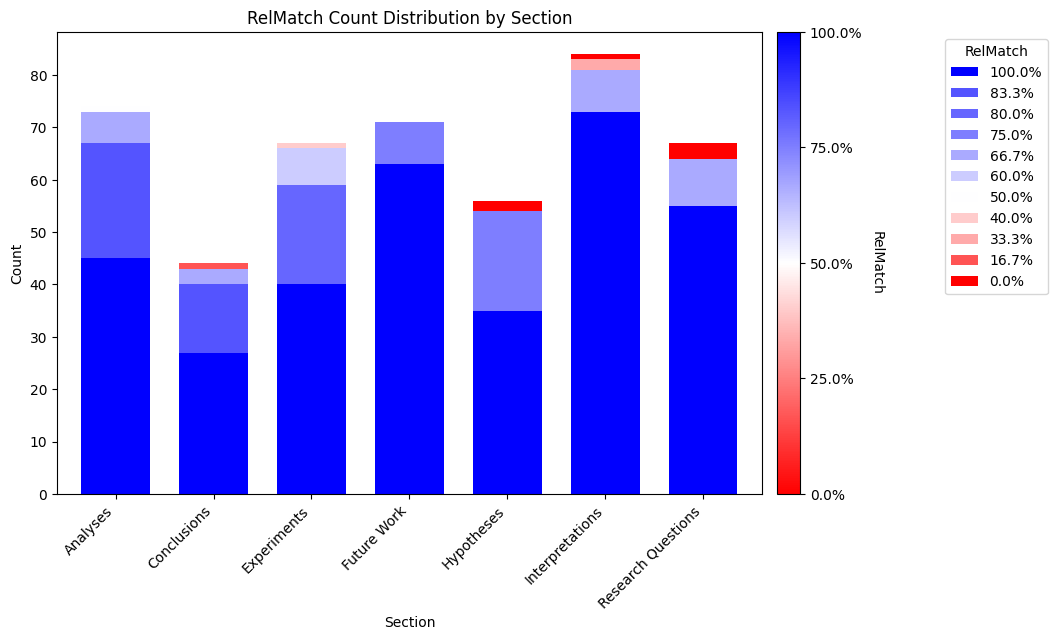

In [179]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter

# Prepare data
plot_df = (
    unique_relmatch_counts
    .pivot(index="Section", columns="RelMatch", values="Count")
    .sort_index(axis=1, ascending=False)
)

relmatch_values = plot_df.columns.astype(float)

# Color mapping: RelMatch 0.0 = red, 1.0 = blue
cmap = plt.colormaps["bwr_r"]
norm = Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in relmatch_values]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax,
    width=0.7,
    edgecolor="none"
)

# Labels
ax.set(
    xlabel="Section",
    ylabel="Count",
    title="RelMatch Count Distribution by Section"
)

# Rotate x-axis labels
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

# Move legend further right
ax.legend(
    title="RelMatch",
    labels=[f"{v:.1%}" for v in relmatch_values],
    bbox_to_anchor=(1.25, 1),
    loc="upper left"
)

# Continuous colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.04,
    pad=0.02
)

cbar.set_label("RelMatch", rotation=270, labelpad=15)
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1, decimals=1)
)

# Reserve space on the right for both colorbar and legend
fig.subplots_adjust(right=0.75)

plt.show()

In [180]:
unique_relmatch_percentage = (
    result_match_item
    .groupby(['Section', 'RelMatch'])
    .size()
    .reset_index(name='Count')
    .assign(
        Percentage=lambda df: (
            df['Count']
            / df.groupby('Section')['Count'].transform('sum')
        )
    )
    .sort_values(['Section', 'Percentage'], ascending=[True, False])
)

unique_relmatch_percentage['Percentage'] *= 100

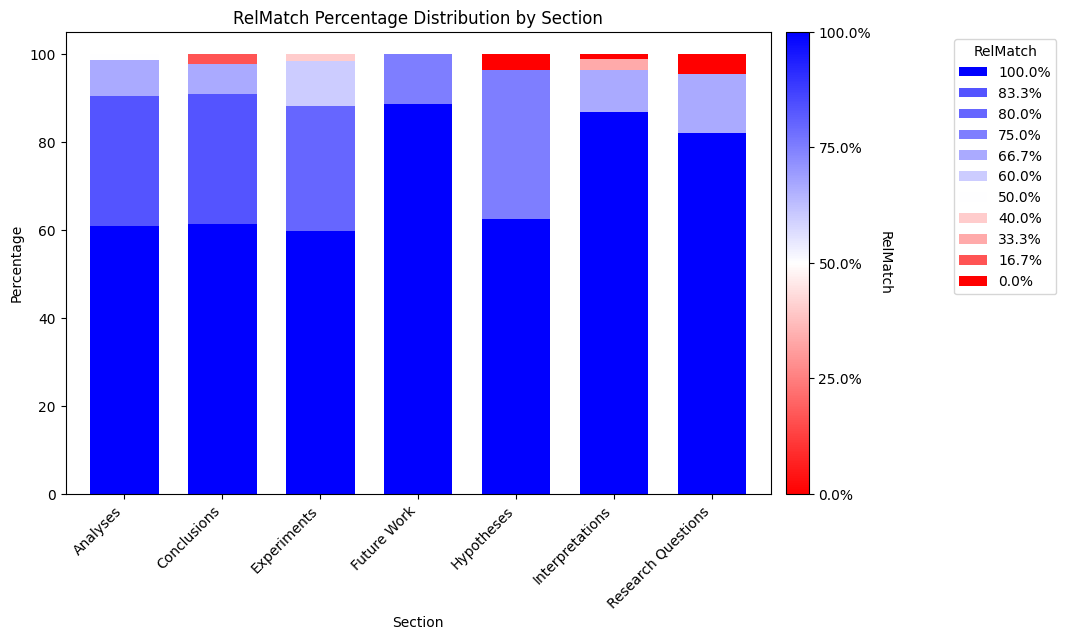

In [181]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter

# Prepare data
plot_df = (
    unique_relmatch_percentage
    .pivot(index="Section", columns="RelMatch", values="Percentage")
    .sort_index(axis=1, ascending=False)
)

relmatch_values = plot_df.columns.astype(float)

# Color mapping: RelMatch 0.0 = red, 1.0 = blue
cmap = plt.colormaps["bwr_r"]
norm = Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in relmatch_values]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax,
    width=0.7,
    edgecolor="none"
)

# Labels
ax.set(
    xlabel="Section",
    ylabel="Percentage",
    title="RelMatch Percentage Distribution by Section"
)

# Rotate x-axis labels
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

# Move legend further right
ax.legend(
    title="RelMatch",
    labels=[f"{v:.1%}" for v in relmatch_values],
    bbox_to_anchor=(1.25, 1),
    loc="upper left"
)

# Continuous colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.04,
    pad=0.02
)

cbar.set_label("RelMatch", rotation=270, labelpad=15)
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1, decimals=1)
)

# Reserve space on the right for both colorbar and legend
fig.subplots_adjust(right=0.75)

plt.show()

In [195]:
cdfs = comparison_df.groupby('Section')
for name, cdf in cdfs:
    print(f"Section: {name}")
    for s in cdf['Field'].sort_values().unique():
        print(f"  Field: {s} - Type: {type(cdf[(cdf['Field'] == s) & (cdf['Ground Truth'] != 'EXTRA KEY IN LLM OUTPUT') & (cdf['LLM'] != 'MISSING')]['Ground Truth'].iloc[0])}")
    print('\n')

Section: Analyses
  Field: Analyses Experiments - Type: <class 'list'>
  Field: Analyses Metrics - Type: <class 'list'>
  Field: Analyses Reason - Type: <class 'str'>
  Field: Analyses Results - Type: <class 'dict'>
  Field: Analyses Statistics - Type: <class 'list'>
  Field: Analyses Test - Type: <class 'str'>


Section: Conclusions
  Field: Conclusions Hypotheses - Type: <class 'list'>
  Field: Conclusions Interpretations - Type: <class 'list'>
  Field: Conclusions Reason - Type: <class 'str'>
  Field: Conclusions Research_questions - Type: <class 'list'>
  Field: Conclusions Support - Type: <class 'list'>
  Field: Conclusions Value - Type: <class 'str'>


Section: Experiments
  Field: Experiments Data - Type: <class 'list'>
  Field: Experiments Experiment_description - Type: <class 'str'>
  Field: Experiments Hypotheses - Type: <class 'list'>
  Field: Experiments Research_questions - Type: <class 'list'>
  Field: Experiments Strategy - Type: <class 'str'>


Section: Future Work
  Fi

In [ ]:
import numpy as np

likart = pd.read_csv('output.csv')

def calculate_similarity(x) -> tuple:
    """
    Calculate similarity between LLM and Ground Truth values.
    Returns a tuple of (similarity, similarity_metric) where similarity is a float and similarity_metric is a string.
    """
    # Dealing with missing and extra values. No similarity if either is missing or extra.
    if x['LLM'] == "MISSING" or x['Ground Truth'] == "EXTRA KEY IN LLM OUTPUT":
        return np.nan, "Missing/Extra Values"
    
    # Dealing with likart score fields.
    if "Value" in x['Field']:
        likart_score = likart.loc[(likart['Paper'] == x['Paper']) & (likart['section'] == x['Item']), 'value']
        if likart_score.empty:
            raise ValueError(f"ERROR: No Likert score found for Paper: {x['Paper']}, Section: {x['Item']}")
        likart_score = likart_score.iloc[0]
        if likart_score == 1:
            return 1.0, "Likert Score 1"
        if (likart_score == 2) & (x['LLM'] == x['Ground Truth']):
            return 1.0, "Likert Score 2"
        return 0.0, "No Match or poor Likert Score"
    
    if isinstance(x['LLM'], list) and isinstance(x['Ground Truth'], list):
        llm_set = set(x['LLM'])
        gt_set = set(x['Ground Truth'])
        if "Conclusions Support" in x['Field']:
            llm_set = set([f"{c}_{i}" for i, c in enumerate(x['LLM'])])
            gt_set = set([f"{c}_{i}" for i, c in enumerate(x['Ground Truth'])])
        true_positive = len(llm_set & gt_set)
        false_positive = len(llm_set - gt_set)
        false_negative = len(gt_set - llm_set)

        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0

        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall > 0
            else 0
        )
                
        return f1, "List F1 Score"
    
    if isinstance(x['LLM'], str) and isinstance(x['Ground Truth'], str):
        return 1.0 if x['LLM'] == x['Ground Truth'] else 0.0, "String Match 1/0"
    
    if isinstance(x['LLM'], (int, float)) and isinstance(x['Ground Truth'], (int, float)):
        return 1.0 if x['LLM'] == x['Ground Truth'] else 0.0, "Numeric Match 1/0"
    
    if isinstance(x['LLM'], bool) and isinstance(x['Ground Truth'], bool):
        return 1.0 if x['LLM'] == x['Ground Truth'] else 0.0, "Boolean Match 1/0"
    
    if isinstance(x['LLM'], dict) and isinstance(x['Ground Truth'], dict):
        llm_keys = set(x['LLM'].keys())
        gt_keys = set(x['Ground Truth'].keys())
        true_positive = len(llm_keys & gt_keys)
        false_positive = len(llm_keys - gt_keys)
        false_negative = len(gt_keys - llm_keys)

        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0

        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall > 0
            else 0
        )
                
        return f1, "Dict F1 Score"
    
    return 0.0, "type unknown - No Match"
    
comparison_df[['Similarity', 'Similarity_metric']] = comparison_df.apply(lambda row: calculate_similarity(row), axis=1)

Field: Experiments Strategy, Item: experiment_1, LLM: 10-fold cross-validation repeated 10 times (100 total runs). Random split (train = 0.8, validation = 0.1, test = 0.1)., Ground Truth: Random split (train = 0.8, validation = 0.1, test = 0.1), repeated 100 times.
Field: Hypotheses Research_questions, Item: hypothesis_1, LLM: ['research_question_2', 'research_question_3'], Ground Truth: ['research_question_1', 'research_question_2', 'research_question_3']
Field: Interpretations Reason, Item: interpretation_1, LLM: Found in Section 4.3. The authors interpret the boxplots (Figure 5) to show that RUGS successfully matches the performance of continuous updates., Ground Truth: Found in Section 4.3. The authors interpret the boxplots (Figure 5) and the table 2 to show that RUGS successfully matches the performance of continuous updates.
Field: Experiments Strategy, Item: experiment_1, LLM: Multi-objective Bayesian optimization (BoTorch/Optuna) with Gaussian process surrogate and EHVI acquis

In [ ]:
comparison_df

count    1987.000000
mean        0.946250
std         0.216962
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Similarity, dtype: float64